In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Reproducibilidad
torch.manual_seed(42)
torch.cuda.manual_seed(42)

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_EPOCHS = 25
LEARNING_RATE = 0.001
NUM_CLASSES = 2

In [ ]:
# Focal Loss personalizada
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        CE_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-CE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * CE_loss
        return F_loss.mean()

In [ ]:
# Transformaciones de datos
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.42, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.GaussianBlur(3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dataset = datasets.ImageFolder("/content/drive/MyDrive/midataset/train", transform=train_transforms)
val_dataset = datasets.ImageFolder("/content/drive/MyDrive/midataset/val", transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [ ]:
# Entrenamiento con fine-tuning progresivo
def train_model(model, optimizer, scheduler, train_loader, criterion, freeze_epochs=5, total_epochs=NUM_EPOCHS):
    # Congelar todas menos la capa final
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters() if hasattr(model, 'fc') else model.classifier.parameters():
        param.requires_grad = True

    model.train()
    for epoch in range(total_epochs):
        running_loss = 0.0

        if epoch == freeze_epochs:
            print("\nDescongelando todas las capas para fine-tuning completo...")
            for param in model.parameters():
                param.requires_grad = True

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()
        print(f"Epoch [{epoch+1}/{total_epochs}], Loss: {running_loss/len(train_loader):.4f}")

In [ ]:
# Cargar y preparar modelos preentrenados
model_names = ["resnet50", "efficientnet_b0", "regnet_y_400mf"]
models_dict = {}
optimizers = {}
schedulers = {}

for name in model_names:
    model = getattr(models, name)(pretrained=True)
    if hasattr(model, 'fc'):
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    elif hasattr(model, 'classifier'):
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)

    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    models_dict[name] = model
    optimizers[name] = optimizer
    schedulers[name] = scheduler

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed i

In [ ]:
# Entrenar modelos individualmente
criterion = FocalLoss()
save_dir = "/content/drive/MyDrive/modelos_ensamblados"
os.makedirs(save_dir, exist_ok=True)

for name in model_names:
    print(f"\nEntrenando {name}...")
    train_model(models_dict[name], optimizers[name], schedulers[name], train_loader, criterion)
    torch.save(models_dict[name].state_dict(), os.path.join(save_dir, f"{name}.pth"))


Entrenando resnet50...
Epoch [1/25], Loss: 0.0172
Epoch [2/25], Loss: 0.0103
Epoch [3/25], Loss: 0.0080
Epoch [4/25], Loss: 0.0076
Epoch [5/25], Loss: 0.0088

Descongelando todas las capas para fine-tuning completo...
Epoch [6/25], Loss: 0.0122
Epoch [7/25], Loss: 0.0017
Epoch [8/25], Loss: 0.0020
Epoch [9/25], Loss: 0.0021
Epoch [10/25], Loss: 0.0011
Epoch [11/25], Loss: 0.0012
Epoch [12/25], Loss: 0.0014
Epoch [13/25], Loss: 0.0010
Epoch [14/25], Loss: 0.0004
Epoch [15/25], Loss: 0.0006
Epoch [16/25], Loss: 0.0004
Epoch [17/25], Loss: 0.0008
Epoch [18/25], Loss: 0.0005
Epoch [19/25], Loss: 0.0002
Epoch [20/25], Loss: 0.0001
Epoch [21/25], Loss: 0.0002
Epoch [22/25], Loss: 0.0002
Epoch [23/25], Loss: 0.0001
Epoch [24/25], Loss: 0.0001
Epoch [25/25], Loss: 0.0001

Entrenando efficientnet_b0...
Epoch [1/25], Loss: 0.0125
Epoch [2/25], Loss: 0.0085
Epoch [3/25], Loss: 0.0083
Epoch [4/25], Loss: 0.0081
Epoch [5/25], Loss: 0.0075

Descongelando todas las capas para fine-tuning completo...

In [ ]:
# Predicción usando promedio de softmax
@torch.no_grad()
def ensemble_predict_softmax(models_list, dataloader):
    all_preds = []
    true_labels = []

    for inputs, labels in dataloader:
        inputs = inputs.to(DEVICE)
        outputs = [torch.softmax(model(inputs), dim=1).cpu().numpy() for model in models_list]
        avg_output = np.mean(outputs, axis=0)
        final_preds = avg_output.argmax(axis=1)

        all_preds.extend(final_preds)
        true_labels.extend(labels.numpy())

    return np.array(true_labels), np.array(all_preds)

In [ ]:
# Evaluar el ensemble
model_instances = []
for name in model_names:
    model = getattr(models, name)(pretrained=False)
    if hasattr(model, 'fc'):
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    elif hasattr(model, 'classifier'):
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    model.load_state_dict(torch.load(os.path.join(save_dir, f"{name}.pth"), map_location=DEVICE))
    model.to(DEVICE)
    model.eval()
    model_instances.append(model)

true_labels, ensemble_preds = ensemble_predict_softmax(model_instances, val_loader)

acc = accuracy_score(true_labels, ensemble_preds)
prec = precision_score(true_labels, ensemble_preds, average='macro')
rec = recall_score(true_labels, ensemble_preds, average='macro')
f1 = f1_score(true_labels, ensemble_preds, average='macro')

print("\nMétricas del modelo ensamblado (softmax promedio):")
print(f"Precisión: {acc:.4f}")
print(f"Precisión Macro: {prec:.4f}")
print(f"Recall Macro: {rec:.4f}")
print(f"F1 Score Macro: {f1:.4f}")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Métricas del modelo ensamblado (softmax promedio):
Precisión: 1.0000
Precisión Macro: 1.0000
Recall Macro: 1.0000
F1 Score Macro: 1.0000


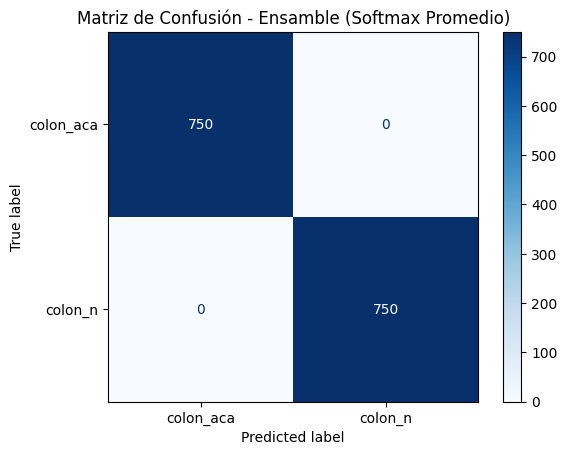

In [ ]:
cm = confusion_matrix(true_labels, ensemble_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=val_dataset.classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Ensamble (Softmax Promedio)")
plt.show()